In [4]:
import polars as pl
import numpy as np
import ast
import matplotlib.pyplot as plt
import librosa.display
import librosa
from tqdm import tqdm
from joblib import Parallel, delayed
from sklearn.metrics import f1_score, average_precision_score,roc_auc_score

from DataProcessing import *
from configue_isaac import *

In [2]:
df = load_and_clean_dataset(DATA_CSV, AUDIO_DIR)
names=np.unique(df["class_name"].to_list())

--- Traitement du CSV : Data/train.csv ---


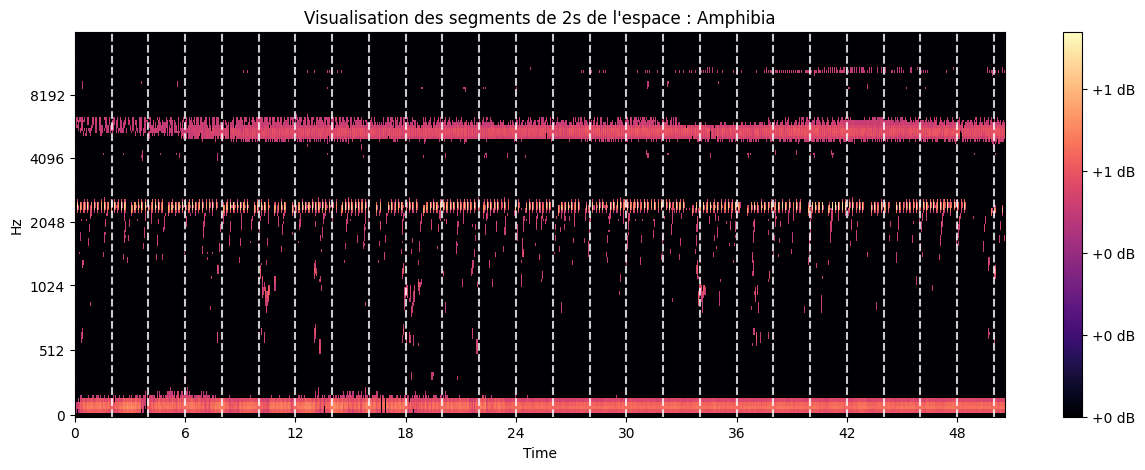

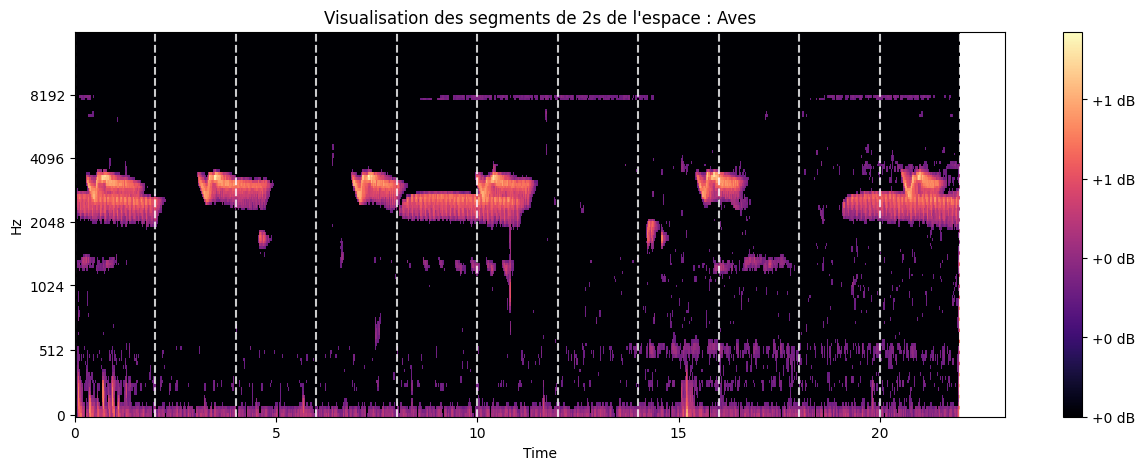

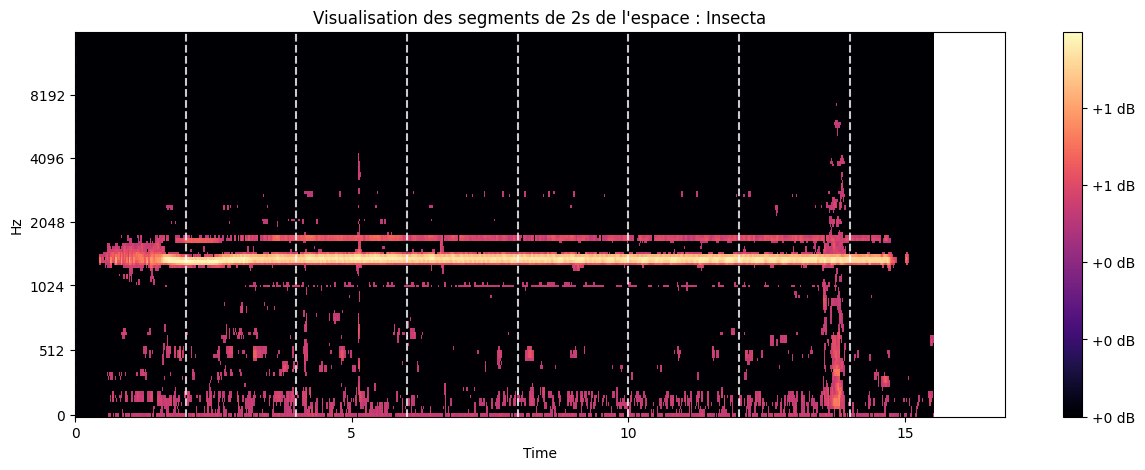

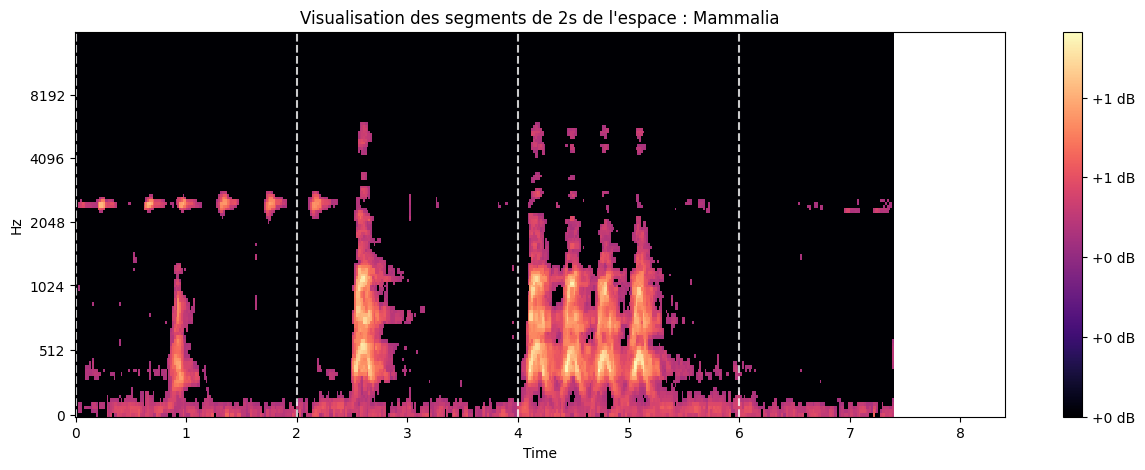

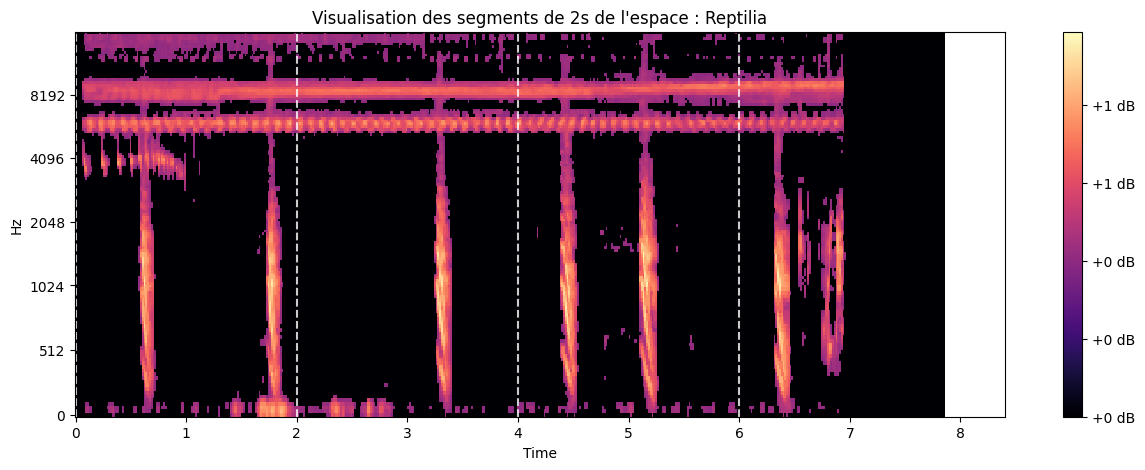

In [3]:
def plot_mel( S_dB,sr,audio_dur,segment_dur=2,class_name="None"):
    plt.figure(figsize=(15, 5))
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')

    # traits tous les segment_dur secondes adaptés à la durée réelle
    for i in range(0, int(np.ceil(audio_dur)) + 1, segment_dur):
        plt.axvline(x=i, color='white', linestyle='--', alpha=0.8)

    plt.title(f"Visualisation des segments de {segment_dur}s de l'espace : {class_name}")
    plt.colorbar(format='%+2.0f dB')
    plt.show()

# teste-le sur un oiseau au hasard
names=np.unique(df["class_name"].to_list())
for name in names[:-1]:
    S_dB,sr,audio_dur = get_mel(df.filter(df["class_name"] == name)["full_path"][50])
    plot_mel( S_dB,sr,audio_dur,class_name=name)

S_dB,sr,audio_dur = get_mel(df.filter(df["class_name"] == names[-1])["full_path"][0])
plot_mel( S_dB,sr,audio_dur,class_name=names[-1])

In [ ]:
df_ic = compute_ic_df(df)

/Users/isaac/Library/Python/3.9/lib/python/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=279
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=836
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=384
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=557
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=256
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal

In [ ]:
def process_file_safe(row):
    try:
        return process_file(row["full_path"], row["common_name"])
    except:
        return []

rows_list = Parallel(n_jobs=-1, backend="loky")(
    delayed(process_file_safe)(row) 
    for row in tqdm(list(df.iter_rows(named=True)), total=len(df), position=0, leave=True)
)

all_rows = [r for sublist in rows_list for r in sublist]
df_features = pl.DataFrame(all_rows)
df_features.write_parquet("mfcc_features.parquet")
print(df_features.shape)
print(df_features.columns)

 47%|████▋     | 16784/35549 [05:52<05:19, 58.69it/s] /Users/isaac/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 35549/35549 [11:43<00:00, 50.50it/s] 


(230375, 2)
['common_name', 'features']


In [ ]:
# toutes les espèces possibles
all_species = sorted(df["common_name"].unique().to_list())
species_to_idx = {s: i for i, s in enumerate(all_species)}
print(f"{len(all_species)} espèces")
# mapping primary_label -> common_name
label_map = dict(zip(df["primary_label"].to_list(), df["common_name"].to_list()))

def get_all_labels(row):
    labels = set()
    labels.add(row["common_name"])
    try:
        secondary = ast.literal_eval(row["secondary_labels"])
        for code in secondary:
            if code in label_map:
                labels.add(label_map[code])
    except:
        pass
    return list(labels)

def process_file_multilabel(path, row, sr=32000, segment_dur=5):
    y, _ = librosa.load(path, sr=sr)
    segment_len = sr * segment_dur
    labels = get_all_labels(row)
    
    label_vec = np.zeros(len(all_species), dtype=np.float32)
    for l in labels:
        if l in species_to_idx:
            label_vec[species_to_idx[l]] = 1.0
    
    rows = []
    for start in range(0, len(y) - segment_len, segment_len):
        segment = y[start:start + segment_len]
        features = extract_mfcc(segment, sr)
        rows.append({
            "features": features.tolist(),
            "labels": label_vec.tolist()
        })
    return rows

def process_file_safe_ml(row):
    try:
        return process_file_multilabel(row["full_path"], row)
    except:
        return []

rows_list = Parallel(n_jobs=-1, backend="loky")(
    delayed(process_file_safe_ml)(row)
    for row in tqdm(list(df.iter_rows(named=True)), total=len(df), position=0, leave=True)
)

all_rows = [r for sublist in rows_list for r in sublist]
df_features_ml = pl.DataFrame(all_rows)
df_features_ml.write_parquet("mfcc_features_multilabel.parquet")
print(df_features_ml.shape)

206 espèces


100%|██████████| 35549/35549 [10:12<00:00, 58.01it/s]  


(230375, 2)


In [9]:
from sklearn.multioutput import MultiOutputClassifier
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

df_features = pl.read_parquet("mfcc_features_multilabel.parquet")

# prépare x et y
X = np.array(df_features["features"].to_list())
Y = np.array(df_features["labels"].to_list())  # shape (n_segments, 233)

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(X.shape, Y.shape)

(230375, 160) (230375, 206)


In [14]:
base_model = lgb.LGBMClassifier(
    n_estimators=100,  # réduit de 300 à 100
    num_leaves=31,    
    n_jobs=-1,
    verbose=50
)

model = MultiOutputClassifier(base_model, n_jobs=-1)
model.fit(X_train, Y_train)
Y_pred_proba = np.array([m.predict_proba(X_val)[:, 1] for m in model.estimators_]).T

cols_with_positives = Y_val.sum(axis=0) > 0
auc = roc_auc_score(Y_val[:, cols_with_positives], Y_pred_proba[:, cols_with_positives], average='macro')
print(f"ROC-AUC macro : {auc:.4f}")

[LightGBM] [Info] Number of positive: 2645, number of negative: 181655
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.001068
[LightGBM] [Debug] init for col-wise cost 0.000009 seconds, init for row-wise cost 0.046090 seconds
[LightGBM] [Info] Number of positive: 657, number of negative: 183643
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.068568 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Number of positive: 1277, number of negative: 183023
[LightGBM] [Info] Total Bins 40800
[LightGBM] [Info] Number of positive: 875, number of negative: 183425
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.001068
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.001068
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.001068
[LightGBM] [Info] Number of positive: 344, number of negative: 183956
[LightGBM] [Debug] Dataset::GetMultiBinFrom

/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

ROC-AUC macro : 0.8023


In [ ]:
all_species = sorted(df["common_name"].unique().to_list())
species_to_idx = {s: i for i, s in enumerate(all_species)}
print(f"Nombre d'espèces détectées : {len(all_species)}")

label_map = dict(zip(df["primary_label"].to_list(), df["common_name"].to_list()))

# get_all_labels doit etre globale pour joblib
import ast

def get_all_labels(row):
    """ Extrait le label principal et les labels secondaires d'une ligne """
    labels = set()
    labels.add(row["common_name"])
    try:
        # tente de parser la liste des secondary_labels
        secondary = ast.literal_eval(row["secondary_labels"])
        for code in secondary:
            if code in label_map:
                labels.add(label_map[code])
    except Exception:
        pass
    return list(labels)

def process_file_multilabel_opt(row, sr=32000, segment_dur=5):
    """ Charge le fichier, le découpe en 5s, extrait les features et ajoute lat/lon """
    path = row["full_path"]
    try:
        y, _ = librosa.load(path, sr=sr)
    except:
        return[]  # ignore les fichiers corrompus
        
    segment_len = sr * segment_dur
    labels = get_all_labels(row)
    
    # vecteur cible multi-label (ohe)
    label_vec = np.zeros(len(all_species), dtype=np.float32)
    for l in labels:
        if l in species_to_idx:
            label_vec[species_to_idx[l]] = 1.0
            
    # ajout des coordonnees et du mois
    lat = row.get("latitude", 0.0)
    lon = row.get("longitude", 0.0)
    
    rows =[]
    # decoupage en segments de 5s
    for start in range(0, len(y) - segment_len + 1, segment_len):
        segment = y[start:start + segment_len]
        
        # extraction des features
        features = extract_optimized_features(segment, sr=sr)
        
        rows.append({
            "filename": path.split('/')[-1],
            "start_sec": start / sr,
            "latitude": lat,
            "longitude": lon,
            "features": features.tolist(),
            "labels": label_vec.tolist()
        })
        
    return rows

def process_file_safe_ml_opt(row):
    try:
        return process_file_multilabel_opt(row)
    except Exception as e:
        print(f"Erreur sur {row['full_path']}: {e}")
        return []
# exécution parallèle et export polars

print(f"Extraction des 158 features sur {len(df)} fichiers audio...")

rows_list = Parallel(n_jobs=-1, backend="loky")(
    delayed(process_file_safe_ml_opt)(row)
    for row in tqdm(list(df.iter_rows(named=True)), total=len(df))
)

all_rows = [r for sublist in rows_list for r in sublist]

# création du dataframe polars
df_features_ml = pl.DataFrame(all_rows)

# sauvegarde format liste
df_features_ml.write_parquet("features_birdclef_158_compact.parquet")
print(f" Fichier parquet généré. Shape: {df_features_ml.shape}")
print("Nombre de lignes extraites :", len(all_rows))
print("Éclatement des 158 features en colonnes distinctes pour LightGBM...")

df_exploded = df_features_ml.with_columns([
    pl.col("features").list.get(i).alias(f"feat_{i}") for i in range(158)
]).drop("features")

df_exploded.write_parquet("features_birdclef_158.parquet")

Nombre d'espèces détectées : 206
Extraction des 158 features sur 35549 fichiers audio...


100%|██████████| 35549/35549 [31:57<00:00, 18.54it/s]  


✅ Fichier parquet généré. Shape: (230500, 6)
Nombre de lignes extraites : 230500
Éclatement des 158 features en colonnes distinctes pour LightGBM...


In [ ]:
import polars as pl
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import roc_auc_score, f1_score

# chargement et préparation des données
df = pl.read_parquet("features_birdclef_158.parquet")

# on définit les colonnes de features (les 158 de l'audio + les métadonnées)
feature_cols =[f"feat_{i}" for i in range(158)] + ["latitude", "longitude"]

# extraction des x (features)
X = df.select(feature_cols).to_numpy()

# extraction des y (labels multi-classes en one-hot encoding)
# conversion de la colonne labels en matrice 2d
y = np.vstack(df["labels"].to_list())

print(f"Shape X (Features) : {X.shape}")
print(f"Shape Y (Labels)   : {y.shape}")

# split train/test classique
# on pourrait faire un stratifiedgroupkfold
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# définition et entraînement du modèle
print("\nConfiguration de LightGBM...")

# le modèle de base (un classifieur binaire pour une espèce)
base_lgbm = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=7,
    class_weight='balanced',  # crucial en birdclef car les espèces sont très déséquilibrées
    random_state=42,
    n_jobs=1,  # on met à 1 car on va paralléliser au niveau du multioutput
    verbose=-1
)

# le wrapper multi-label (entraîne un lgbm par oiseau)
# parallelisation de l'entrainement
model = MultiOutputClassifier(base_lgbm, n_jobs=-1)

print("Entraînement en cours (cela peut prendre quelques minutes selon le nombre d'espèces)...")
model.fit(X_train, y_train)

# évaluation (métriques birclef)
print("\nPrédictions sur le set de test...")
# predict_proba renvoie une liste de matrices
# reformatage en matrice (n_samples, n_classes)
preds_proba_list = model.predict_proba(X_test)
y_pred_proba = np.array([preds[:, 1] for preds in preds_proba_list]).T

# seuil pour les prédictions binaires (f1-score)
threshold = 0.5
y_pred_bin = (y_pred_proba > threshold).astype(int)

# calcul du roc-auc moyen sur toutes les classes (métriques classique kaggle)
# on utilise average='macro' pour donner le même poids aux espèces rares qu'aux communes
try:
    roc_auc = roc_auc_score(y_test, y_pred_proba, average='macro')
    print(f" Macro ROC-AUC Score : {roc_auc:.4f}")
except ValueError:
    print("Attention: Certaines classes n'ont pas d'exemples dans le set de test.")

f1 = f1_score(y_test, y_pred_bin, average='macro')
print(f" Macro F1-Score (Seuil={threshold}) : {f1:.4f}")

# feature importance (le retour vers toi)
# importance des features
print("\nCalcul des Features Importances...")

# on fait la moyenne de l'importance des features de tous les modèles (toutes les espèces)
importances = np.mean([est.feature_importances_ for est in model.estimators_], axis=0)

# création d'un petit dataframe pour trier et visualiser
importance_df = pl.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort("Importance", descending=True)

print(" Top 10 des Features les plus importantes :")
print(importance_df.head(10))

useless_features = importance_df.filter(pl.col("Importance") < 1.0)
print(useless_features.head(10))

Shape X (Features) : (230500, 160)
Shape Y (Labels)   : (230500, 206)

Configuration de LightGBM...
Entraînement en cours (cela peut prendre quelques minutes selon le nombre d'espèces)...

Prédictions sur le set de test...


/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

🔥 Macro ROC-AUC Score : nan
🔥 Macro F1-Score (Seuil=0.5) : 0.4866

Calcul des Features Importances...
🏆 Top 10 des Features les plus importantes :
shape: (10, 2)
┌───────────┬────────────┐
│ Feature   ┆ Importance │
│ ---       ┆ ---        │
│ str       ┆ f64        │
╞═══════════╪════════════╡
│ latitude  ┆ 360.407767 │
│ longitude ┆ 341.703883 │
│ feat_114  ┆ 63.84466   │
│ feat_108  ┆ 61.15534   │
│ feat_1    ┆ 59.291262  │
│ feat_0    ┆ 49.854369  │
│ feat_113  ┆ 48.0       │
│ feat_3    ┆ 46.529126  │
│ feat_119  ┆ 45.61165   │
│ feat_111  ┆ 44.529126  │
└───────────┴────────────┘

🗑️ Features inutiles (Gain = 0) que tu peux supprimer de ton script d'extraction :
Nombre de features avec 0 importance : 0
shape: (0, 2)
┌─────────┬────────────┐
│ Feature ┆ Importance │
│ ---     ┆ ---        │
│ str     ┆ f64        │
╞═════════╪════════════╡
└─────────┴────────────┘


/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
valid_classes = np.where(y_test.sum(axis=0) > 0)[0]

roc_auc = roc_auc_score(
    y_test[:, valid_classes],
    y_pred_proba[:, valid_classes],
    average='macro'
)

print(f"Macro ROC-AUC (BirdCLEF) : {roc_auc:.4f}")


Macro ROC-AUC (BirdCLEF) : 0.9753


In [30]:
df_soud = pl.read_csv("Data/train_soundscapes_labels.csv")
df_soud.head()

filename,start,end,primary_label
str,str,str,str
"""BC2026_Train_0039_S22_20211231…","""00:00:00""","""00:00:05""","""22961;23158;24321;517063;65380"""
"""BC2026_Train_0039_S22_20211231…","""00:00:05""","""00:00:10""","""22961;23158;24321;517063;65380"""
"""BC2026_Train_0039_S22_20211231…","""00:00:10""","""00:00:15""","""22961;23158;24321;517063;65380"""
"""BC2026_Train_0039_S22_20211231…","""00:00:15""","""00:00:20""","""22961;23158;24321;517063;65380"""
"""BC2026_Train_0039_S22_20211231…","""00:00:20""","""00:00:25""","""22961;23158;24321;517063;65380"""


In [31]:
df_soud = df_soud .with_columns(
    pl.col("primary_label")
    .str.split(";")  # sépare la chaîne en liste
    .alias("primary_label")  # remplace la colonne existante
)

df_soud = df_soud.with_columns(
    (pl.lit("Data/train_soundscapes/") + pl.col("filename"))
    .alias("full_path")  # renomme la colonne résultante
)
df_soud.drop_in_place("filename")
df_soud

start,end,primary_label,full_path
str,str,list[str],str
"""00:00:00""","""00:00:05""","[""22961"", ""23158"", … ""65380""]","""Data/train_soundscapes/BC2026_…"
"""00:00:05""","""00:00:10""","[""22961"", ""23158"", … ""65380""]","""Data/train_soundscapes/BC2026_…"
"""00:00:10""","""00:00:15""","[""22961"", ""23158"", … ""65380""]","""Data/train_soundscapes/BC2026_…"
"""00:00:15""","""00:00:20""","[""22961"", ""23158"", … ""65380""]","""Data/train_soundscapes/BC2026_…"
"""00:00:20""","""00:00:25""","[""22961"", ""23158"", … ""65380""]","""Data/train_soundscapes/BC2026_…"
…,…,…,…
"""00:00:35""","""00:00:40""","[""555146"", ""65380""]","""Data/train_soundscapes/BC2026_…"
"""00:00:40""","""00:00:45""","[""517063"", ""555146""]","""Data/train_soundscapes/BC2026_…"
"""00:00:45""","""00:00:50""","[""517063"", ""555146""]","""Data/train_soundscapes/BC2026_…"


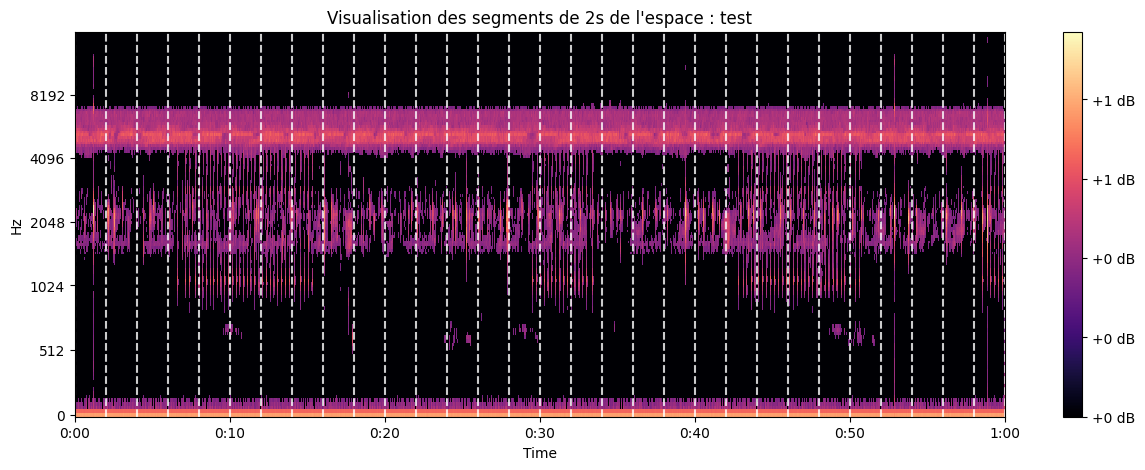

In [34]:
S_dB,sr,audio_dur = get_mel(df_soud["full_path"][1200])
plot_mel( S_dB,sr,audio_dur,class_name="test")

In [36]:
def time_str_to_sec(time_str):
    """ Convertit 'HH:MM:SS' ou 'MM:SS' en secondes """
    parts = time_str.split(':')
    if len(parts) == 3:
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
    elif len(parts) == 2:
        return int(parts[0]) * 60 + float(parts[1])
    return float(time_str)

def parse_labels(label_data):
    """ Transforme la colonne primary_label en une vraie liste Python """
    # si polars lit la liste comme un string '["22961", "23158"]'
    if isinstance(label_data, str):
        try:
            return ast.literal_eval(label_data)
        except:
            return []
    # si c'est déjà une liste polars
    elif isinstance(label_data, list) or isinstance(label_data, pl.Series):
        return list(label_data)
    return []

def process_soundscape_file(file_path, df_file, species_to_idx, sr=32000):
    """
    Charge l'audio une seule fois, puis itère sur toutes les fenêtres 
    temporelles du dataset associées à ce fichier.
    """
    try:
        y, _ = librosa.load(file_path, sr=sr)
    except Exception as e:
        print(f"Erreur de chargement sur {file_path}: {e}")
        return []
    
    pantanal_lat = -19.05
    pantanal_lon = -56.75
    rows = []
    
    # on itère sur les lignes qui correspondent à ce fichier
    for row in df_file.iter_rows(named=True):
        # découpage temporel
        start_sec = time_str_to_sec(row["start"])
        end_sec = time_str_to_sec(row["end"])
        
        start_sample = int(start_sec * sr)
        end_sample = int(end_sec * sr)
        
        segment = y[start_sample:end_sample]
        
        # si le segment est trop court (ex: fin de fichier), on peut l'ignorer ou le padder
        if len(segment) < (sr * 1):  # ignore les segments de moins de 1 seconde
            continue
            
        # extraction des 158 features
        try:
            features = extract_optimized_features(segment, sr=sr)
        except Exception as e:
            print(f"Erreur d'extraction sur segment {start_sec}-{end_sec}: {e}")
            continue

        # encodage one-hot des labels cibles
        labels_list = parse_labels(row["primary_label"])
        label_vec = np.zeros(len(species_to_idx), dtype=np.float32)
        
        for l in labels_list:
            if l in species_to_idx:
                label_vec[species_to_idx[l]] = 1.0
        
        rows.append({
            "filename": file_path.split('/')[-1],
            "start_sec": start_sec,
            "end_sec": end_sec,
            "latitude": pantanal_lat,  # ajout de la latitude
            "longitude": pantanal_lon,  # ajout de la longitude
            "features": features.tolist(),
            "labels": label_vec.tolist()
        })
        
    return rows

In [ ]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm  # .auto s'adapte mieux si tu es sur jupyter ou terminal
import polars as pl

print("Groupement des annotations par fichier audio...")
grouped_df = df_soud.group_by("full_path")

# on récupère le nombre total de fichiers exact pour configurer tqdm
total_files = df_soud["full_path"].n_unique()

tasks = (
    # on gère le fait que polars renvoie un tuple : on prend l'index [0]
    delayed(process_soundscape_file)(
        file_path[0] if isinstance(file_path, tuple) else file_path, 
        df_group, 
        species_to_idx
    )
    for file_path, df_group in grouped_df
)

print(f"Extraction des features sur {total_files} soundscapes...")

# joblib pour l'execution parallele
# suivi avec tqdm
rows_list = list(
    tqdm(
        Parallel(n_jobs=-1, backend="loky", return_as="generator")(tasks), 
        total=total_files, 
        desc="Progression", 
        unit=" fichier"
    )
)

# aplatissement de la liste
all_rows = [r for sublist in rows_list for r in sublist]

# dataframe polars final
df_features_soundscapes = pl.DataFrame(all_rows)

print(f" Fichier soundscapes traité. Shape: {df_features_soundscapes.shape}")

# separation des features en colonnes
df_exploded_soundscapes = df_features_soundscapes.with_columns([
    pl.col("features").list.get(i).alias(f"feat_{i}") for i in range(158)
]).drop("features")

# sauvegarde
df_exploded_soundscapes.write_parquet("features_soundscapes_158.parquet")
print(" Fichier Parquet généré avec succès.")

In [41]:
print("1. Chargement des datasets...")
df_audio = pl.read_parquet("features_birdclef_158.parquet")
df_soundscapes = pl.read_parquet("features_soundscapes_158.parquet")

print(f"Shape initial - Audio: {df_audio.shape}, Soundscapes: {df_soundscapes.shape}")

# définition des colonnes à garder
# on prend les 158 features + la position géo + les labels + le nom du fichier pour le suivi
feature_cols = [f"feat_{i}" for i in range(158)]
common_cols = ["filename", "latitude", "longitude", "labels"] + feature_cols

# alignement et fusion
print("\n2. Alignement et fusion des données...")
# on sélectionne uniquement les colonnes communes pour éviter les erreurs de concaténation
df_audio_clean = df_audio.select(common_cols)
df_soundscapes_clean = df_soundscapes.select(common_cols)

# concaténation verticale
df_train = pl.concat([df_audio_clean, df_soundscapes_clean])
print(f" Fusion réussie ! Shape final: {df_train.shape}")

# préparation de x (features) et y (cibles)
print("\n3. Création des matrices X et y pour l'entraînement...")

# x : nos 158 features audio + la latitude et la longitude
cols_for_X = ["latitude", "longitude"] + feature_cols
X = df_train.select(cols_for_X).to_numpy()

# y : on empile les listes (one-hot encoding) pour en faire une belle matrice 2d numpy
y = np.vstack(df_train["labels"].to_list())

print(f"Matrice X (Features) prête : {X.shape}")
print(f"Matrice y (Labels) prête   : {y.shape}")

1. Chargement des datasets...
Shape initial - Audio: (230500, 163), Soundscapes: (1478, 164)

2. Alignement et fusion des données...
✅ Fusion réussie ! Shape final: (231978, 162)

3. Création des matrices X et y pour l'entraînement...
Matrice X (Features) prête : (231978, 160)
Matrice y (Labels) prête   : (231978, 206)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from lightgbm import LGBMClassifier
import numpy as np

X, y, df_train = load_data(audio_path="features_birdclef_158_patched.parquet", soundscapes_path="features_soundscapes_158_patched.parquet")

print("1. Séparation Train / Validation...")
# on garde 20% des données pour vérifier que le modèle ne surapprend pas (overfitting)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille Train : {X_train.shape[0]} échantillons")
print(f"Taille Val   : {X_val.shape[0]} échantillons")

print("\n2. Normalisation des données (StandardScaler)...")
# on cale le scaler uniquement sur le train pour ne pas tricher (data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("\n3. Configuration et Entraînement du LightGBM Multi-Label...")
# paramètres de base pour un bon équilibre entre vitesse et performance
lgbm_base = LGBMClassifier(
    n_estimators=150,  # nombre d'arbres
    learning_rate=0.05,  # vitesse d'apprentissage
    max_depth=8,  # profondeur max des arbres
    subsample=0.8,  # utilise 80% des données par arbre (réduit l'overfitting)
    colsample_bytree=0.8,  # utilise 80% des features par arbre
    random_state=42,
    n_jobs=-1  # utilise tous les coeurs cpu dispos
)

# on l'enveloppe pour qu'il gère les prédictions multiples (plusieurs oiseaux en même temps)
# parallelisation sur tous les coeurs
multi_target_lgbm = MultiOutputClassifier(lgbm_base, n_jobs=-1)

# entrainement du modele
multi_target_lgbm.fit(X_train_scaled, y_train)
print(" Entraînement terminé !")

print("\n4. Évaluation sur le set de Validation...")
# on demande les probabilités (entre 0 et 1) plutôt que juste 0 ou 1
# conversion en matrice 2d
y_pred_proba_list = multi_target_lgbm.predict_proba(X_val_scaled)
y_pred_proba = np.array([preds[:, 1] for preds in y_pred_proba_list]).T

# seuil de décision : on dit qu'un oiseau est là si la probabilité dépasse 0.5
y_pred_bin = (y_pred_proba > 0.5).astype(int)

# calcul des scores (macro = moyenne équitable entre les espèces rares et communes)
f1 = f1_score(y_val, y_pred_bin, average='macro', zero_division=0)
map_score = average_precision_score(y_val, y_pred_proba, average='macro')

print(f" Score F1 (Macro) : {f1:.4f}  <-- Mesure l'équilibre Précision/Rappel")
print(f" Score mAP        : {map_score:.4f}  <-- Mesure la qualité de ton classement par probabilités")

1. Chargement des datasets...
Shape initial - Audio: (230500, 163), Soundscapes: (1478, 164)

2. Alignement et fusion des données...
✅ Fusion réussie ! Shape final: (231978, 162)

3. Création des matrices X et y pour l'entraînement...
Matrice X (Features) prête : (231978, 160)
Matrice y (Labels) prête   : (231978, 234)
1. Séparation Train / Validation...
Taille Train : 185582 échantillons
Taille Val   : 46396 échantillons

2. Normalisation des données (StandardScaler)...

3. Configuration et Entraînement du LightGBM Multi-Label...
[LightGBM] [Info] Number of positive: 13, number of negative: 185569
[LightGBM] [Info] Number of positive: 31, number of negative: 185551
[LightGBM] [Info] Number of positive: 1, number of negative: 185581
[LightGBM] [Info] Number of positive: 48, number of negative: 185534
[LightGBM] [Info] Number of positive: 22, number of negative: 185560
[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 0, number of negative: 185582
[Light

/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

🎯 Score F1 (Macro) : 0.4350  <-- Mesure l'équilibre Précision/Rappel
🎯 Score mAP        : 0.5216  <-- Mesure la qualité de ton classement par probabilités


In [5]:
print("\n4. Évaluation sur le set de Validation...")

# np.array pour eviter les warnings
y_pred_proba_list = multi_target_lgbm.predict_proba(np.array(X_val_scaled))
y_pred_proba = np.array([preds[:, 1] for preds in y_pred_proba_list]).T

# seuil de décision
y_pred_bin = (y_pred_proba > 0.5).astype(int)

# score f1 et map
f1 = f1_score(y_val, y_pred_bin, average='macro', zero_division=0)
map_score = average_precision_score(y_val, y_pred_proba, average='macro')

# roc-auc (sur les classes valides de ton set de validation)
valid_classes = np.where(y_val.sum(axis=0) > 0)[0]

roc_auc = roc_auc_score(
    y_val[:, valid_classes],
    y_pred_proba[:, valid_classes],
    average='macro'
)

print(f" Score F1 (Macro) : {f1:.4f}")
print(f" Score mAP        : {map_score:.4f}")
print(f" Score ROC-AUC    : {roc_auc:.4f}")


4. Évaluation sur le set de Validation...


/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/isaac/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

🎯 Score F1 (Macro) : 0.4350
🎯 Score mAP        : 0.5216
🎯 Score ROC-AUC    : 0.8932
